In [ ]:
from google.colab import files
uploaded = files.upload()

Saving raw_customer_sales.xlsx to raw_customer_sales.xlsx


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel("raw_customer_sales.xlsx")
df.head()

,Customer_ID,Name,Gender,DOB,Email,Country,Purchase_Date,Product,Category,Price,Quantity,Payment_Method
0,C001,Anil Kumar,M,1999-05-14,anil@gmail.com,India,2024/01/15,Laptop,Electronics,55000,1.0,Credit Card
1,C002,Sneha Reddy,F,2001-08-22,sneha@gmail.com,India,15-02-2024,Mobile,Electronics,20000,2.0,Debit Card
2,C003,Rahul Sharma,M,1998-12-05,NaN,India,2024-03-10,Headphones,Electronics,1500,1.0,UPI
3,C004,Priya Singh,F,2000/07/18,priya@gmail,India,2024-04-05,Tablet,Electronics,25000,1.0,Credit Card
4,C005,Amit Verma,M,1997-03-25,amit@gmail.com,India,05/05/2024,Camera,Electronics,70000,1.0,Debit Card


In [ ]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     13 non-null     object 
 1   Name            13 non-null     object 
 2   Gender          13 non-null     object 
 3   DOB             12 non-null     object 
 4   Email           12 non-null     object 
 5   Country         13 non-null     object 
 6   Purchase_Date   13 non-null     object 
 7   Product         13 non-null     object 
 8   Category        13 non-null     object 
 9   Price           13 non-null     int64  
 10  Quantity        12 non-null     float64
 11  Payment_Method  13 non-null     object 
dtypes: float64(1), int64(1), object(10)
memory usage: 1.3+ KB


Index(['Customer_ID', 'Name', 'Gender', 'DOB', 'Email', 'Country',
       'Purchase_Date', 'Product', 'Category', 'Price', 'Quantity',
       'Payment_Method'],
      dtype='object')

In [ ]:
data_dict = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Description": [
        "Unique customer ID",
        "Customer name",
        "Gender",
        "Date of Birth",
        "Email ID",
        "Country",
        "Purchase Date",
        "Product name",
        "Product category",
        "Price of product",
        "Quantity purchased",
        "Paymet method"
    ]
})
data_dict

,Column Name,Data Type,Description
0,Customer_ID,object,Unique customer ID
1,Name,object,Customer name
2,Gender,object,Gender
3,DOB,object,Date of Birth
4,Email,object,Email ID
5,Country,object,Country
6,Purchase_Date,object,Purchase Date
7,Product,object,Product name
8,Category,object,Product category
9,Price,int64,Price of product


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
data_dict.to_excel("data_dictionary.xlsx",index=False)

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Gender,0
DOB,1
Email,1
Country,0
Purchase_Date,0
Product,0
Category,0
Price,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.nunique()

,0
Customer_ID,12
Name,12
Gender,2
DOB,11
Email,11
Country,1
Purchase_Date,12
Product,6
Category,1
Price,10


In [ ]:
df = df.drop_duplicates()

In [ ]:
df['Email'] = df['Email'].fillna("navyasri@gmail.com")
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['DOB'] = df['DOB'].fillna("2005-10-05")

In [ ]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'],errors='coerce')
df['DOB'] = pd.to_datetime(df['DOB'],errors='coerce')

In [ ]:
df['Email'] = df['Email'].apply(lambda x:x if "@" in str(x) else "invalid@gmail.com")

In [ ]:
df = df[(df['Price'] > 0) & (df['Price'] < 200000)]

In [ ]:
df['Age'] = (pd.Timestamp.now() - df['DOB']).dt.days//365

In [ ]:
df['Quantity'] = df['Quantity'].astype(int)

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 0 to 12
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Customer_ID     10 non-null     object        
 1   Name            10 non-null     object        
 2   Gender          10 non-null     object        
 3   DOB             9 non-null      datetime64[ns]
 4   Email           10 non-null     object        
 5   Country         10 non-null     object        
 6   Purchase_Date   1 non-null      datetime64[ns]
 7   Product         10 non-null     object        
 8   Category        10 non-null     object        
 9   Price           10 non-null     int64         
 10  Quantity        10 non-null     int64         
 11  Payment_Method  10 non-null     object        
 12  Age             9 non-null      float64       
dtypes: datetime64[ns](2), float64(1), int64(2), object(8)
memory usage: 1.1+ KB


,DOB,Purchase_Date,Price,Quantity,Age
count,9,1,10.000000,10.000000,9.000000
mean,2000-08-29 00:00:00,2024-01-15 00:00:00,39150.000000,1.400000,25.222222
min,1995-09-10 00:00:00,2024-01-15 00:00:00,1500.000000,1.000000,20.000000
25%,1998-12-05 00:00:00,2024-01-15 00:00:00,18500.000000,1.000000,23.000000
50%,2001-04-17 00:00:00,2024-01-15 00:00:00,25000.000000,1.000000,25.000000
75%,2002-11-30 00:00:00,2024-01-15 00:00:00,55000.000000,1.750000,27.000000
max,2005-10-05 00:00:00,2024-01-15 00:00:00,120000.000000,3.000000,30.000000
std,NaN,NaN,36519.439268,0.699206,3.153481


In [ ]:
df.to_excel("cleaned_customer_sales.xlsx",index=False)

In [ ]:
files.download("cleaned_customer_sales.xlsx")
files.download("data_dictionary.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

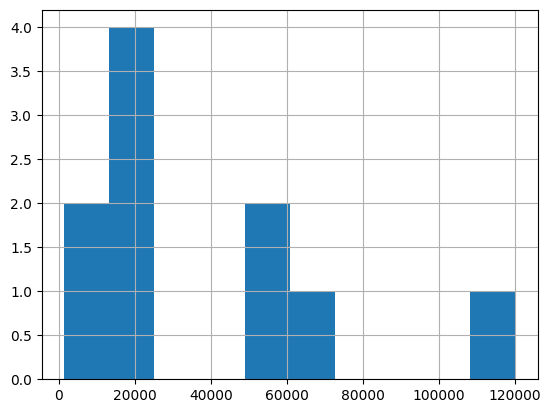

In [ ]:
import matplotlib.pyplot as plt
df['Price'].hist()
plt.show()

# New Section